In [460]:
import sys
# map the path where the module file is located. In my case it was the desktop
sys.path.append('/home/paola/Documentos/flaring-spi-master/notebooks')

In [461]:
import warnings

warnings.simplefilter("ignore")
#from altaipony.lcio import from_mast
#from funcs.detrend import custom_detrending, estimate_detrended_noise
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

%matplotlib inline


In [462]:
search_result = search_lightcurve("AU Mic") 
lc2min = search_result[3].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.normalize().remove_nans()

In [463]:
x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

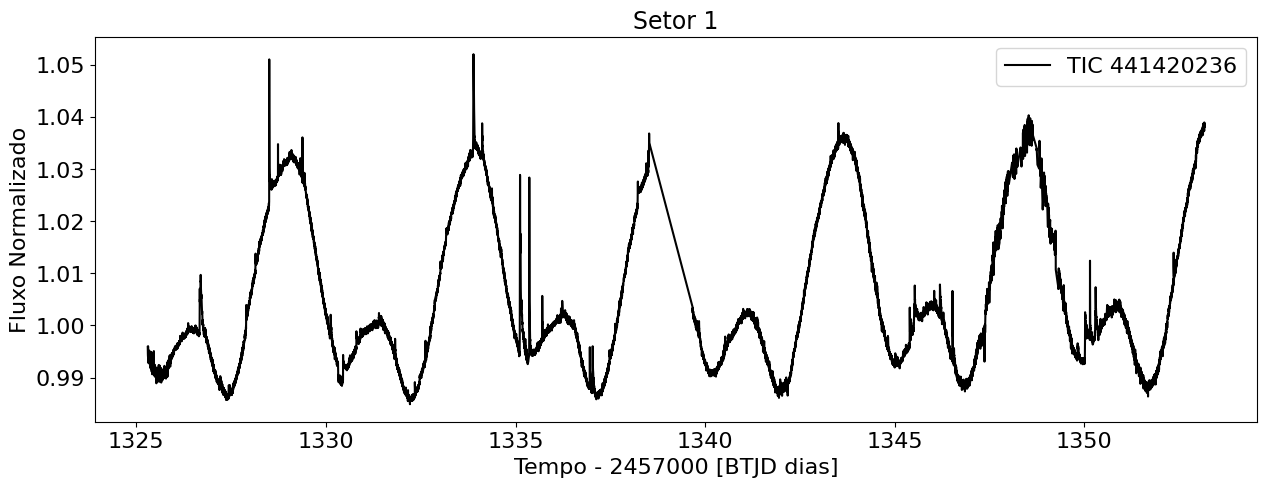

In [464]:
#%matplotlib notebook
plt.rcParams['font.size'] = '16' 
fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x2min,y2min,'k')
labels= ["TIC 441420236"]
ax.set_xlabel('Tempo - 2457000 [BTJD dias]').set_fontsize(16)
ax.set_ylabel('Fluxo Normalizado').set_fontsize(16)  
plt.title('Setor 1').set_fontsize(17)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.legend(labels) 
plt.show()


In [479]:
flcd = lc2_m.flatten(window_length=300, polyorder=3, return_trend=True, break_tolerance=4, niters=3, sigma=2.5, mask=None)

In [488]:
x_detrend = np.ascontiguousarray(flcd[1].time.value, dtype=np.float64) 
y_detrend = np.ascontiguousarray(flcd[1].flux, dtype=np.float64)
yerr_detrend= np.ascontiguousarray(flcd[1].flux_err, dtype=np.float64)

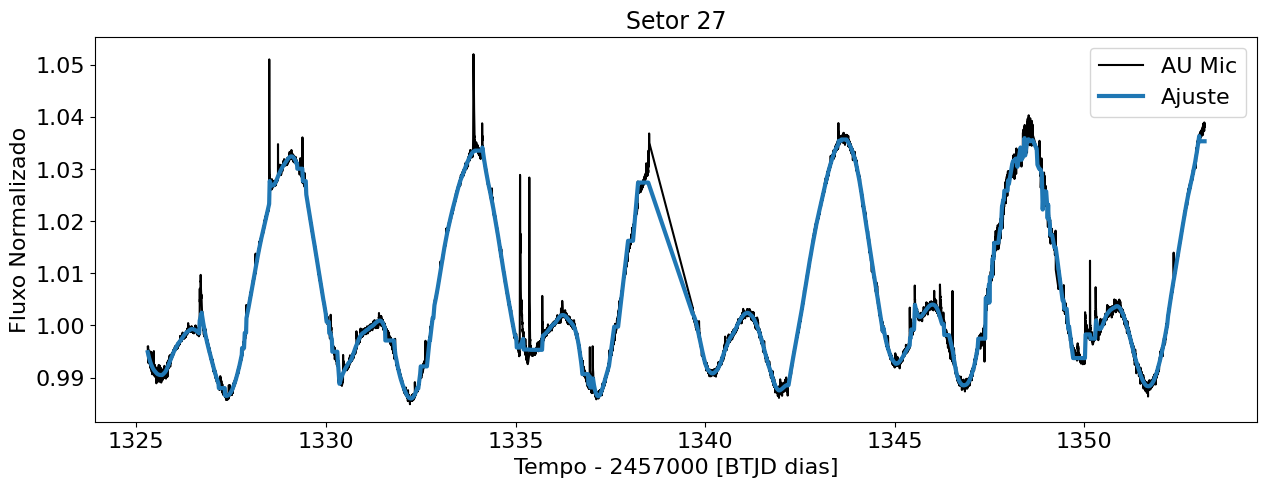

In [487]:
import lightkurve as lk
import matplotlib.pyplot as plt

# Supondo que você já tenha realizado o ajuste e tem os dados ajustados em "flcd"
# e a tendência ajustada em "trend"

fig, ax = plt.subplots(1, 1, figsize=(15, 5))

# Plot dos dados originais
ax.plot(x2min, y2min, 'k', label='AU Mic')

# Plot da tendência ajustada
ax.plot(x_detrend,y_detrend, linewidth=3, label="Ajuste")

ax.set_title('Setor 27', fontsize=17)
ax.set_ylabel("Fluxo Normalizado")
ax.set_xlabel("Tempo - 2457000 [BTJD dias]")

# Adicione outras configurações do gráfico, se necessário

ax.legend()
plt.show()


In [477]:
import numpy as np
import matplotlib.pyplot as plt
%mathplotlib notebook

# Criação do gráfico com os três plots sobrepostos
fig, ax = plt.subplots(1, 1, figsize=(15, 5))

# Plot 1
ax.plot(x2min, y2min, 'k', label='AU Mic')
ax.set_title('Setor 27')
ax.set_ylabel("Fluxo Normalizado")

# Plot 2 (sobreposto)
ax.plot(x2min, y_detrend, 'b', label='Ajuste')

# Plot 3 (sobreposto)
ax.plot(x2min, y_residual, 'r', label='Resíduos')

# Definindo rótulos e legendas
ax.set_xlabel("Tempo - 2457000 [BTJD dias]")
ax.legend()

# Exibindo o gráfico
plt.show()


UsageError: Line magic function `%mathplotlib` not found.


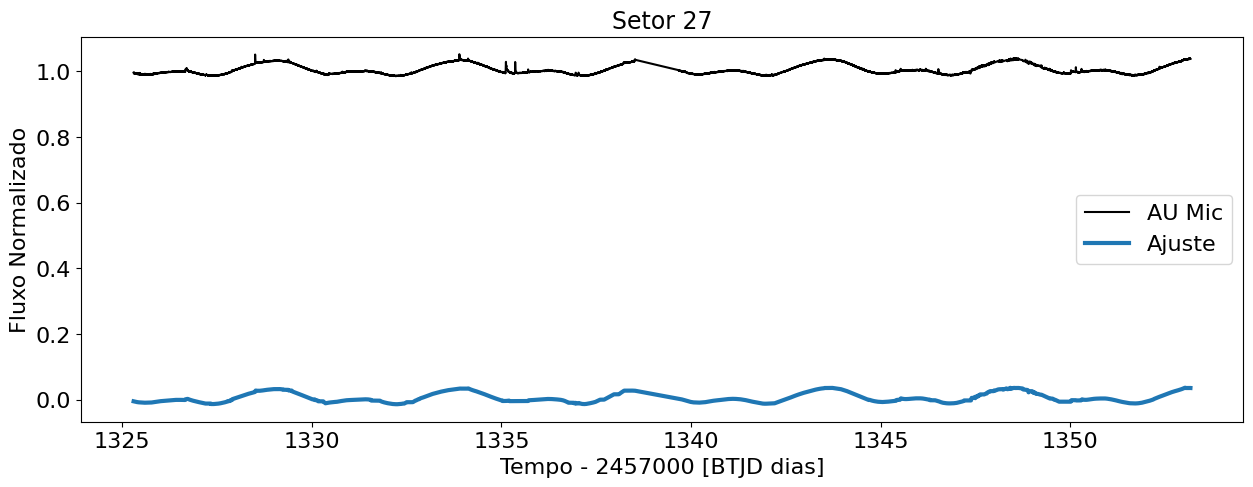

In [473]:
fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x2min,y2min,'k',label = 'AU Mic',)
plt.plot(x2min,y2min-y_detrend, linewidth=3, label="Ajuste")
plt.title('Setor 27').set_fontsize(17)
plt.ylabel("Fluxo Normalizado")
plt.xlabel("Tempo - 2457000 [BTJD dias]")

#ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True).set_fontsize(16)

ax.legend()

In [ ]:
x_detrend = np.ascontiguousarray(flcd.time.value, dtype=np.float64) 
y_detrend = np.ascontiguousarray(flcd.flux, dtype=np.float64)
yerr_detrend= np.ascontiguousarray(flcd.flux_err, dtype=np.float64)

In [ ]:
%matplotlib inline

fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x_detrend,y_detrend,'k.',label = 'TIC 441420236',)
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()

In [ ]:
flcd.to_fits(path='demo-lightcurve.fits', overwrite=True)

In [ ]:
#Transformando os arquivos em fits e salvando 
from astropy.io import fits
hdu = fits.open('demo-lightcurve.fits')
type(hdu)

In [ ]:
hdu.info()

In [ ]:
hdu[1].header #abrindo para saber do roler 

In [ ]:
tbdata = hdu[1].data

In [ ]:
from astropy.table import Table
dat = Table.read('demo-lightcurve.fits', format='fits')
df = dat.to_pandas()

In [ ]:
print(df.isna().sum()) #Contagem de dados nans nas colunas
df = df.dropna(subset=['TIME']) 
df = df.dropna(subset=['QUALITY']) # retirar valores 
print(df.isna().sum())
df.drop(df[df.QUALITY>0].index ,inplace=True) # exclui linhas onde flag com raios cósmicos

In [ ]:
%matplotlib inline
time=df["TIME"] # tempo
flux=df["FLUX"] #flux
s=df["QUALITY"] # sap_quality
sf  = df['QUALITY'] > 1 # filtra flag com valores maiores que 1 ou seja flag 128 e 8192, são raios cósmicos
#from scipy.signal import savgol_filter
rf = np.mean(flux)/np.mean(flux) #Fluxo relativo

In [ ]:
%matplotlib inline

fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(time,flux, 'k*-')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()

In [ ]:
#%matplotlib notebook
#Calculando a média simples dos dados 
y_mean = [np.median(flux)]*len(time)

fig,ax = plt.subplots(1,1,figsize=(15,5))

data_line = ax.plot(time,flux, label='Dados', marker='.', color='black')

mean_line = ax.plot(time,y_mean+np.array(np.std(flux)), label='Média+$\sigma$', linestyle='--', color = 'red')
#mean_line = ax.plot(time,y_mean+np.std(flux), label='Mean+std', linestyle='--', color = 'red')

#Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()
plt.show()


In [ ]:
#%matplotlib notebook
#Calculando a média simples dos dados 
y_mean = [np.median(flux)]*len(time)

fig,ax = plt.subplots(1,1,figsize=(15,5))

data_line = ax.plot(time,flux, label='Dados', marker='.', color='black')

mean_line = ax.plot(time,y_mean+np.array(np.std(flux)), label='Média+$\sigma$', linestyle='--', color = 'red')
#mean_line = ax.plot(time,y_mean+np.std(flux), label='Mean+std', linestyle='--', color = 'red')

#Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()
plt.show()


In [ ]:
from wotan import flatten


In [ ]:
flatten_lc, trend_lc = flatten(time, flux, window_length=0.5, method='biweight', return_trend=True)
%matplotlib notebook
plt.scatter(time, flux, s=1, color='black')
plt.plot(time, trend_lc, color='red', linewidth=2)
plt.show()


In [ ]:
df['FLATTEN'] = flatten_lc

In [ ]:
x = np.mean(flux)
print(x)

In [ ]:
import pandas as pd
fl129=pd.read_csv('paola_flares1.csv') #lendo os flares setor 1
tess_f = pd.read_csv('tess_function.csv') #lendo os arquivos da função de resposta
#tess_f = np.loadtxt('flaresE.txt')
df = pd.DataFrame(fl129)
tf = pd.DataFrame(tess_f)

In [ ]:
#Definição das funções
from PyAstronomy.pyasl import planck

#Constantes 
nm= np.array(tf["nm"]) # comprimento de onda em nm
ry= np.array(tf["ry"]) # tess function response
c = 2.99792458e18 # speed of light, in [A/s]
Teff= 3700# temperatura efetiva au mic
Tflare=10000# temperatura flare
raio=0.75*6.968e+8 # raio solar
sb1=5.67051e-5
#Bs=planck(nm,Teff)
#Bf=planck(nm, Tflare)

#############################################################################################

h, c, kB = 6.62606957e-34, 299792458, 1.3806488e-23
#temperature, K
T_star = 3700
T_flare = 10000
lambda_min = nm.min()# 300    # nm
lambda_max = nm.max()#2000   # nm
n = 264
wv = np.linspace(lambda_min, lambda_max, n)

Bs= 2*h*c**2/(wv*1.e-9)**5/(np.exp(h*c/wv/1.e-9/kB/ T_star)- 1)
Bf=2*h*c**2/(wv*1.e-9)**5/(np.exp(h*c/wv/1.e-9/kB/T_flare)-1)




#Duração da flare
def dur(start,stop):
    dur1=abs(stop[0]-start[0])*1440
    #return dur1
    print("%.5f" %dur1, "min")
    #dur1=abs(stop[1]-start[1])
    #print("diferença:", "%.5f" %dur1, "min", "inicio:", "%.5f" %start[1],"fim:", "%.5f" %stop[1], "")
    #print("inicio:", "%.5f" %start,"fim:", "%.5f" %stop, "min")
    
#Tempo de subida e descida
def subdes(start,stop):
    maximo = start[1]
    maximo_t = 0.0
    for i in range(len(time)):
        if time[i]>start[0] and time[i]<stop[0]:
            if flux[i]> maximo:
                maximo = flux[i]
                maximo_t = time[i]
    rise=(maximo_t-start[0])*1440
    decay=(stop[0]-maximo_t)*1440
    print("Subida:", "%.5f" %rise, "min", "Descida:", "%.5f" %decay, "min")
    print("maximo", maximo)
    #print("inicio, fim", start[0],stop[0])
    #print("duração", (stop[0]-start[0])*1440)
    #print("duração2", (rise+decay))
    

def ampl(start,stop):
    maximo = start[1]
    minimo = start[1]
    med = np.mean(flux)
    for i in range(len(time)):
        if time[i]>start[0] and time[i]<stop[0]:
            if flux[i]> maximo:
                maximo = flux[i]
            if flux[i] < minimo:
                minimo = flux[i]  
    amplitude = maximo-minimo 
    print(amplitude)
    


def flare(start,stop):
    flux_flare = []
    tempo_flare = []
    for i in range(len(time)):
        if time[i]>start[0] and time[i]<stop[0]:
            flux_flare.append(flux[i])
            tempo_flare.append(time[i])
            
    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    
    #Integral 
    Aflare=flux_flare*(np.pi)*raio**2
    Aflare1=simps(ry*Teff*Bs)/simps(ry*Tflare*Bf)
    #Area total da flare 
    Atotal=Aflare*Aflare1
    #Luminosidade
    L=sb1*Tflare**4*Atotal 
    #Energia bolemetrica da Flare
    E1=simps(L*tempo_flare) 
    
    #print('%.5e' %E1, "ergs")
    print('%.5e' %E1)
    
def flare2(start,stop):
    flux_flare = []
    tempo_flare = []
    for i in range(len(time)):
        if time[i]>start[0] and time[i]<stop[0]:
            flux_flare.append(flux[i])
            tempo_flare.append(time[i])
            
    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    
    #Integral 
    Aflare=flux_flare*(np.pi)*raio**2
    Aflare1=trapezoid(ry*Teff*Bs)/trapezoid(ry*Tflare*Bf)
    #Area total da flare 
    Atotal=Aflare*Aflare1
    #Luminosidade
    L=sb1*Tflare**4*Atotal 
    #Energia bolemetrica da Flare
    E1=trapezoid(L*tempo_flare) 
    
    #print('%.5e' %E1, "ergs")
    print('%.5e' %E1)

In [ ]:
#Definição das funções
from PyAstronomy.pyasl import planck

#Constantes 
nm= np.array(tf["nm"]) # comprimento de onda em nm
ry= np.array(tf["ry"]) # tess function response
#c = 2.99792458e18 # speed of light, in [A/s]

Teff= 3700# temperatura efetiva au mic
Tflare=10000# temperatura flare
raio=0.75*6.957e+10 # raio solar cm
sb1=5.67051e-5 #ergs cm-2*s-1*K-4

# Essa função da em [W/(m**2 m)]
Bs=planck(Teff,lam=nm)*1e-7  #função de plank com a temperatura da estrela #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
Bf=planck(Tflare,lam=nm)*1e-7  #função de plank com a flare


def ener_flare(start,stop):
    flux_flare = []
    tempo_flare = []
    for i in range(len(time)):
        if time[i]>start[0] and time[i]<stop[0]:
            flux_flare.append(flux[i])
            tempo_flare.append(time[i])
            
    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    
    #Integral 
    
    Aflare=flux_flare*(np.pi)*raio**2
    Aflare1=simps(y=ry*Bs,x=nm)/simps(y=ry*Bf,x=nm)
    
    #Area total da flare 
    Atotal=Aflare*Aflare1
    
    #Luminosidade da flare
    L=(sb1)*(Tflare**4)*(Atotal) 
    
    #Energia bolemetrica da Flare
    E1=simps(y=L,x =tempo_flare) 
    
    #print(Tflare**4)
    print('%.5e' %E1)


In [ ]:
#Flares selecionadas
flare1_i = df.iloc[0,0],df.iloc[0,1]
flare1_f = df.iloc[0,2],df.iloc[0,3]
##########################
flare2_i = df.iloc[1,0],df.iloc[1,1]
flare2_f = df.iloc[1,2],df.iloc[1,3]
##########################
flare3_i = df.iloc[2,0],df.iloc[2,1]
flare3_f = df.iloc[2,2],df.iloc[2,3]
##########################
flare4_i = df.iloc[3,0],df.iloc[3,1]
flare4_f = df.iloc[3,2],df.iloc[3,3]
##########################
flare5_i = df.iloc[4,0],df.iloc[4,1]
flare5_f = df.iloc[4,2],df.iloc[4,3]
##########################
flare6_i = df.iloc[5,0],df.iloc[5,1]
flare6_f = df.iloc[5,2],df.iloc[5,3]
##########################
flare7_i = df.iloc[6,0],df.iloc[6,1]
flare7_f = df.iloc[6,2],df.iloc[6,3]
##########################
flare8_i = df.iloc[7,0],df.iloc[7,1]
flare8_f = df.iloc[7,2],df.iloc[7,3]
##########################
flare9_i = df.iloc[8,0],df.iloc[8,1]
flare9_f = df.iloc[8,2],df.iloc[8,3]
##########################
flare10_i = df.iloc[9,0],df.iloc[9,1]
flare10_f = df.iloc[9,2],df.iloc[9,3]
##########################
flare11_i = df.iloc[10,0],df.iloc[10,1]
flare11_f = df.iloc[10,2],df.iloc[10,3]
##########################
flare12_i = df.iloc[11,0],df.iloc[11,1]
flare12_f = df.iloc[11,2],df.iloc[11,3]
##########################
flare13_i = df.iloc[12,0],df.iloc[12,1]
flare13_f = df.iloc[12,2],df.iloc[12,3]
##########################
flare14_i = df.iloc[13,0],df.iloc[13,1]
flare14_f = df.iloc[13,2],df.iloc[13,3]
##########################
flare15_i = df.iloc[14,0],df.iloc[14,1]
flare15_f = df.iloc[14,2],df.iloc[14,3]
##########################
flare16_i = df.iloc[15,0],df.iloc[15,1]
flare16_f = df.iloc[15,2],df.iloc[15,3]
##########################
flare17_i = df.iloc[16,0],df.iloc[16,1]
flare17_f = df.iloc[16,2],df.iloc[16,3]
##########################
flare18_i = df.iloc[17,0],df.iloc[17,1]
flare18_f = df.iloc[17,2],df.iloc[17,3]
##########################
flare19_i = df.iloc[18,0],df.iloc[18,1]
flare19_f = df.iloc[18,2],df.iloc[18,3]
##########################
flare20_i = df.iloc[19,0],df.iloc[19,1]
flare20_f = df.iloc[19,2],df.iloc[19,3]
##########################
flare21_i = df.iloc[20,0],df.iloc[20,1]
flare21_f = df.iloc[20,2],df.iloc[20,3]
##########################
flare22_i = df.iloc[21,0],df.iloc[21,1]
flare22_f = df.iloc[21,2],df.iloc[21,3]
##########################
flare23_i = df.iloc[22,0],df.iloc[22,1]
flare23_f = df.iloc[22,2],df.iloc[22,3]
##########################
flare24_i = df.iloc[23,0],df.iloc[23,1]
flare24_f = df.iloc[23,2],df.iloc[23,3]
##########################
flare25_i = df.iloc[24,0],df.iloc[24,1]
flare25_f = df.iloc[24,2],df.iloc[24,3]
##########################
flare26_i = df.iloc[25,0],df.iloc[25,1]
flare26_f = df.iloc[25,2],df.iloc[25,3]
##########################
flare27_i = df.iloc[26,0],df.iloc[26,1]
flare27_f = df.iloc[26,2],df.iloc[26,3]
##########################
flare28_i = df.iloc[27,0],df.iloc[27,1]
flare28_f = df.iloc[27,2],df.iloc[27,3]
##########################
flare29_i = df.iloc[28,0],df.iloc[28,1]
flare29_f = df.iloc[28,2],df.iloc[28,3]
##########################
flare30_i = df.iloc[29,0],df.iloc[29,1]
flare30_f = df.iloc[29,2],df.iloc[29,3]


In [ ]:
dur(flare1_i,flare1_f)
dur(flare2_i,flare2_f)
dur(flare3_i,flare3_f)
dur(flare4_i,flare4_f)
dur(flare5_i,flare5_f)
dur(flare6_i,flare6_f)
dur(flare7_i,flare7_f)
dur(flare8_i,flare8_f)
dur(flare9_i,flare9_f)
dur(flare10_i,flare10_f)
dur(flare11_i,flare11_f)
dur(flare12_i,flare12_f)
dur(flare13_i,flare13_f)
dur(flare14_i,flare14_f)
dur(flare15_i,flare15_f)
dur(flare16_i,flare16_f)
dur(flare17_i,flare17_f)
dur(flare18_i,flare18_f)
dur(flare19_i,flare19_f)
dur(flare20_i,flare20_f)
dur(flare21_i,flare21_f)
dur(flare22_i,flare22_f)
dur(flare23_i,flare23_f)
dur(flare24_i,flare24_f)
dur(flare25_i,flare25_f)
dur(flare26_i,flare26_f)
dur(flare27_i,flare27_f)
dur(flare28_i,flare28_f)
dur(flare29_i,flare29_f)
dur(flare30_i,flare30_f)

In [ ]:
subdes(flare1_i,flare1_f)
subdes(flare2_i,flare2_f)
subdes(flare3_i,flare3_f)
subdes(flare4_i,flare4_f)
subdes(flare5_i,flare5_f)
subdes(flare6_i,flare6_f)
subdes(flare7_i,flare7_f)
subdes(flare8_i,flare8_f)
subdes(flare9_i,flare9_f)
subdes(flare10_i,flare10_f)
subdes(flare11_i,flare11_f)
subdes(flare12_i,flare12_f)
subdes(flare13_i,flare13_f)
subdes(flare14_i,flare14_f)
subdes(flare15_i,flare15_f)
subdes(flare16_i,flare16_f)
subdes(flare17_i,flare17_f)
subdes(flare18_i,flare18_f)
subdes(flare19_i,flare19_f)
subdes(flare20_i,flare20_f)
subdes(flare21_i,flare21_f)
subdes(flare22_i,flare22_f)
subdes(flare23_i,flare23_f)
subdes(flare24_i,flare24_f)
subdes(flare25_i,flare25_f)
subdes(flare26_i,flare26_f)
subdes(flare27_i,flare27_f)
subdes(flare28_i,flare28_f)
subdes(flare29_i,flare29_f)
subdes(flare30_i,flare30_f)

In [ ]:
ampl(flare1_i,flare1_f)
ampl(flare2_i,flare2_f)
ampl(flare3_i,flare3_f)
ampl(flare4_i,flare4_f)
ampl(flare5_i,flare5_f)
ampl(flare6_i,flare6_f)
ampl(flare7_i,flare7_f)
ampl(flare8_i,flare8_f)
ampl(flare9_i,flare9_f)
ampl(flare10_i,flare10_f)
ampl(flare11_i,flare11_f)
ampl(flare12_i,flare12_f)
ampl(flare13_i,flare13_f)
ampl(flare14_i,flare14_f)
ampl(flare15_i,flare15_f)
ampl(flare16_i,flare16_f)
ampl(flare17_i,flare17_f)
ampl(flare18_i,flare18_f)
ampl(flare19_i,flare19_f)
ampl(flare20_i,flare20_f)
ampl(flare21_i,flare21_f)
ampl(flare22_i,flare22_f)
ampl(flare23_i,flare23_f)
ampl(flare24_i,flare24_f)
ampl(flare25_i,flare25_f)
ampl(flare26_i,flare26_f)
ampl(flare27_i,flare27_f)
ampl(flare28_i,flare28_f)
ampl(flare29_i,flare29_f)
ampl(flare30_i,flare30_f)

In [ ]:
#Simpson
flare(flare1_i,flare1_f) #Complexa
flare(flare2_i,flare2_f)
flare(flare3_i,flare3_f)
flare(flare4_i,flare4_f)
flare(flare5_i,flare5_f)
flare(flare6_i,flare6_f)
flare(flare7_i,flare7_f)
flare(flare8_i,flare8_f)
flare(flare9_i,flare9_f)
flare(flare10_i,flare10_f)
flare(flare11_i,flare11_f) #Complexa
flare(flare12_i,flare12_f)
flare(flare13_i,flare13_f)
flare(flare14_i,flare14_f)
flare(flare15_i,flare15_f)
flare(flare16_i,flare16_f) #Complexa
flare(flare17_i,flare17_f) #Complexa
flare(flare18_i,flare18_f)
flare(flare19_i,flare19_f) #Complexa
flare(flare20_i,flare20_f)
flare(flare21_i,flare21_f)
flare(flare22_i,flare22_f)
flare(flare23_i,flare23_f)
flare(flare24_i,flare24_f) #Complexa
flare(flare25_i,flare25_f) #Complexa
flare(flare26_i,flare26_f) #Complexa
flare(flare27_i,flare27_f)
flare(flare28_i,flare28_f) #Complexa
flare(flare29_i,flare29_f) #Complexa
flare(flare30_i,flare30_f)

In [ ]:
flare2(flare1_i,flare1_f) #Complexa
flare2(flare11_i,flare11_f) #Complexa
flare2(flare16_i,flare16_f) #Complexa
flare2(flare17_i,flare17_f) #Complexa
flare2(flare19_i,flare19_f) #Complexa
flare2(flare24_i,flare24_f) #Complexa
flare2(flare25_i,flare25_f) #Complexa
flare2(flare26_i,flare26_f) #Complexa
flare2(flare28_i,flare28_f) #Complexa
flare2(flare29_i,flare29_f) #Complexa

In [ ]:
flare2(flare1_i,flare1_f) #Complexa
flare2(flare2_i,flare2_f)
flare2(flare3_i,flare3_f)
flare2(flare4_i,flare4_f)
flare2(flare5_i,flare5_f)
flare2(flare6_i,flare6_f)
flare2(flare7_i,flare7_f)
flare2(flare8_i,flare8_f)
flare2(flare9_i,flare9_f)
flare2(flare10_i,flare10_f)
flare2(flare11_i,flare11_f) #Complexa
flare2(flare12_i,flare12_f)
flare2(flare13_i,flare13_f)
flare2(flare14_i,flare14_f)
flare2(flare15_i,flare15_f)
flare2(flare16_i,flare16_f) #Complexa
flare2(flare17_i,flare17_f) #Complexa
flare2(flare18_i,flare18_f)
flare2(flare19_i,flare19_f) #Complexa
flare2(flare20_i,flare20_f)
flare2(flare21_i,flare21_f)
flare2(flare22_i,flare22_f)
flare2(flare23_i,flare23_f)
flare2(flare24_i,flare24_f) #Complexa
flare2(flare25_i,flare25_f) #Complexa
flare2(flare26_i,flare26_f) #Complexa
flare2(flare27_i,flare27_f)
flare2(flare28_i,flare28_f) #Complexa
flare2(flare29_i,flare29_f) #Complexa
flare2(flare30_i,flare30_f)

In [ ]:
def flare36(start,stop):
    flux_flare = []
    tempo_flare = []
    for i in range(len(time)):
        if time[i]>start[0] and time[i]<stop[0]:
            flux_flare.append(flux[i])
            tempo_flare.append(time[i])
            
    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    
    #Integral 
    Aflare=flux_flare*(np.pi)*raio**2
    Aflare1=simps(ry*Teff*Bs)/simps(ry*Tflare*Bf)
    
    Aflare12=simps(ry*Teff*Bs)
    Aflare13=simps(ry*Tflare*Bf)
    
    #Area total da flare 
    Atotal=Aflare*Aflare1
    #Luminosidade
    L=sb1*Tflare**4*Atotal 
    #Energia bolemetrica da Flare
    E1=simps(L*tempo_flare) 
    
    #print('%.5e' %E1, "ergs")
    print(Aflare)
    print(Aflare12)
    print(Aflare13)

In [ ]:
flare36(flare1_i,flare1_f) #Complexa
#flare36(flare2_i,flare2_f)

In [ ]:
data=np.loadtxt('dados_setor1.txt')
data1=np.loadtxt('dados1_setor1.txt')
dur=data[:,0]
ener=data[:,1]
sub=data1[:,0]
des=data1[:,1]


In [ ]:
%matplotlib inline

fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(np.log10(ener),dur, 'r*')
ax.set(xlabel = 'log[Energia] - ergs', ylabel = 'Duração [min]',rasterized=True)
ax.legend()

In [ ]:
%matplotlib inline

fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(np.log10(ener),np.log(dur)*0.1, 'k*')
ax.set(xlabel = 'log10(Energia) - ergs', ylabel = 'log(Duração)- Min',rasterized=True)
ax.legend()

In [ ]:
# importar os pacotes necessários
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
# criar modelo linear e otimizar
lm_model = LinearRegression()

lm_model.fit(np.log10(ener).reshape(-1,1),np.log10(dur))

# extrair coeficientes
slope = lm_model.coef_
intercept = lm_model.intercept_

In [ ]:
print("b0: \t{}".format(intercept))
print("b1: \t{}".format(slope[0]))

In [ ]:

plt.scatter(np.log10(ener), np.log10(dur), s=3*30, color = 'black',marker="*")
plt.plot(np.log10(ener), (np.log10(ener) *slope + intercept), color='r')
plt.legend()
plt.ylabel("log10(Duração)[Min]")
plt.xlabel("Log10(Energia)[ergs]")
plt.title('Setor 1')
plt.show()

In [ ]:
x1 = 0.95*np.log10(ener)+29.02

In [ ]:
%matplotlib inline

fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(np.log10(ener),x1, 'k*')
#ax.set(xlabel = 'log10(Energia) - ergs', ylabel = 'log(Duração)- Min',rasterized=True)
ax.legend()

In [ ]:
data=np.loadtxt('dados_setor27.txt')
data2=np.loadtxt('dados1_setor27.txt')
dur2=data[:,0]
ener2=data[:,1]
sub2=data2[:,0]
des2=data2[:,1]


In [ ]:
%matplotlib inline

fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(np.log10(ener2),np.log(dur2), 'r*')
ax.set(xlabel = 'log10(Energia) - ergs', ylabel = 'log(Duração)- Min',rasterized=True)
ax.legend()

In [ ]:
# criar modelo linear e otimizar
lm_model = LinearRegression()

lm_model.fit(np.log10(ener2).reshape(-1,1),np.log10(dur2) )

# extrair coeficientes
slope = lm_model.coef_
intercept = lm_model.intercept_

In [ ]:
print("b0: \t{}".format(intercept))
print("b1: \t{}".format(slope[0]))

In [ ]:
#plt.plot(np.log10(ener2),np.log(dur2), 'b*', s =3)
plt.scatter(np.log10(ener2),np.log10(dur2), s=3*30, color = 'black',marker="*")
plt.plot(np.log10(ener2), (np.log10(ener2) * slope + intercept), color='r')
plt.legend()
plt.ylabel("log10(Duração)[Min]")
plt.xlabel("Log10(Energia)[ergs]")
plt.title('Setor 27')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

n_bins = 10

# Creating distribution
x = np.log10(ener)
y = len(ener)
plt.rcParams['font.size'] = '16'
# Creating histogram
fig, axs = plt.subplots(1, 1,
                        figsize =(10, 7),
                        tight_layout = True)
 
axs.hist(x, bins = n_bins, color='purple', label = "d")
labels= ["Energia"]
plt.ylabel("Quantidade de flares").set_fontsize(16)
plt.xlabel("Log10(Energia)[ergs]").set_fontsize(16)
plt.title('Setor 1').set_fontsize(17)
plt.legend(labels)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
# Show plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

n_bins = 10

# Creating distribution
x = dur
y = len(dur)
plt.rcParams['font.size'] = '16' 
# Creating histogram
fig, axs = plt.subplots(1, 1,
                        figsize =(10, 7),
                        tight_layout = True)
 

axs.hist(x, bins = n_bins, color='gray', label = "d")
labels= ["Duração"]
plt.ylabel("Quantidade de flares").set_fontsize(16)
plt.xlabel("Min").set_fontsize(16)
plt.title('Setor 1').set_fontsize(17)
plt.legend(labels)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
# Show plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

n_bins = 10

# Creating distribution
x = sub
y = len(sub)
plt.rcParams['font.size'] = '16' 
# Creating histogram
fig, axs = plt.subplots(1, 1,
                        figsize =(10, 7),
                        tight_layout = True)
 
axs.hist(x, bins = n_bins)
labels= ["Tempo de subida"]
plt.ylabel("Quantidade de flares").set_fontsize(16)
plt.xlabel("Min").set_fontsize(16)
plt.title('Setor 1').set_fontsize(17)
plt.legend(labels)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
# Show plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

n_bins = 10

# Creating distribution
x = des
y = len(des)
plt.rcParams['font.size'] = '16'  
# Creating histogram
fig, axs = plt.subplots(1, 1,
                        figsize =(10, 7),
                        tight_layout = True)
 
axs.hist(x, bins = n_bins, color='y')
labels= ["Tempo de descida"]
plt.ylabel("Quantidade de flares").set_fontsize(16)
plt.xlabel("Min").set_fontsize(16)
plt.title('Setor 1').set_fontsize(17)
plt.legend(labels)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16) 
# Show plot
plt.show()

In [ ]:
########## Setor 27 Histogramas
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

n_bins = 10

# Creating distribution
x = np.log10(ener2)
y = len(ener2)
plt.rcParams['font.size'] = '16' 
# Creating histogram
fig, axs = plt.subplots(1, 1,
                        figsize =(10, 7),
                        tight_layout = True)
 
axs.hist(x, bins = n_bins, color='purple', label = "d")
labels= ["Energia"]
plt.ylabel("Quantidade de flares").set_fontsize(16)
plt.xlabel("Log10(Energia)[ergs]").set_fontsize(16)
plt.title('Setor 27').set_fontsize(17)
plt.legend(labels)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16) 
# Show plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

n_bins = 10

# Creating distribution
x = dur2
y = len(dur2)
plt.rcParams['font.size'] = '16'  
# Creating histogram
fig, axs = plt.subplots(1, 1,
                        figsize =(10, 7),
                        tight_layout = True)
 
axs.hist(x, bins = n_bins, color='gray', label = "d")
labels= ["Duração"]
plt.ylabel("Quantidade de flares").set_fontsize(16)
plt.xlabel("Min").set_fontsize(16)
plt.title('Setor 27').set_fontsize(17)
plt.legend(labels)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)  
# Show plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

n_bins = 10

# Creating distribution
x = sub2
y = len(sub2)
plt.rcParams['font.size'] = '16'  
# Creating histogram
fig, axs = plt.subplots(1, 1,
                        figsize =(10, 7),
                        tight_layout = True)
 
axs.hist(x, bins = n_bins)
labels= ["Tempo de subida"]
plt.ylabel("Quantidade de flares").set_fontsize(16)
plt.xlabel("Min").set_fontsize(16)
plt.title('Setor 27').set_fontsize(17)
plt.legend(labels) 
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)  
# Show plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

n_bins = 10

# Creating distribution
x = des2
y = len(des2)
plt.rcParams['font.size'] = '16'   
# Creating histogram
fig, axs = plt.subplots(1, 1,
                        figsize =(10, 7),
                        tight_layout = True)
 
axs.hist(x, bins = n_bins, color='y')
labels= ["Tempo de descida"]
plt.ylabel("Quantidade de flares").set_fontsize(16)
plt.xlabel("Min").set_fontsize(16)
plt.title('Setor 27').set_fontsize(17)
plt.legend(labels)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
# Show plot
plt.show()